---
title: "スラブ法についての考察"
description: "光線と軸平行境界ボックスの交差判定に使われるスラブ法の仕組みについて"
date: 2025-07-10T09:00:00+09:00
categories:
  - computerscience
  - slabmethod
draft: false
---

## スラブ法の概要

光線は，始点ベクトル $\boldsymbol{o}$ と方向ベクトル $\boldsymbol{d}$ を用いて，次のようなパラメトリック形式で表される．

$$
\boldsymbol{P}(t)=\boldsymbol{o}+t\boldsymbol{d}
$$

軸平行境界ボックス（Axis-Aligned Bounding Box, AABB）との交点を求めるには，光線が各境界面に到達するパラメータ $t$ を計算すればよい．

$$
\begin{cases}
\boldsymbol{P}(t)=\boldsymbol{b}_{min}\\
\boldsymbol{P}(t)=\boldsymbol{b}_{max}
\end{cases}
$$

各次元 $i$ ごとに，光線がその軸方向のスラブ面（$b_{min,i},b_{max,i}$）に到達するパラメータ値は，次のように求められる．

$$
\begin{align*}
t_{0, i}&=\frac{b_{min,i} - o_{i}}{d_{i}}\\
t_{1, i}&=\frac{b_{max,i} - o_{i}}{d_{i}}
\end{align*}
$$

各軸での交差区間の共通部分から，全体の交差区間を求めることができる．

## テストシーン（共通データセット）

In [1]:
import numpy as np

ro, rd = np.array([1, 2]), np.array([4, 2])
rd = rd / np.linalg.norm(rd)

b_min, b_max = np.array([2, 2]), np.array([4, 4])

t0 = (b_min - ro) / rd
t1 = (b_max - ro) / rd

## スラブのパラメータ区間の可視化

光線パラメータ $t$ を横軸に，縦軸に各軸方向のスラブ区間を並べ，光線がその区間を通過する様子を視覚的に示す．

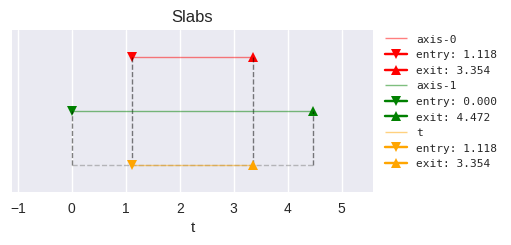

In [2]:
import matplotlib.pyplot as plt
from matplotlib import font_manager


# print(plt.style.available)
plt.style.use("seaborn-v0_8")


def plot_slabs(t0, t1, ax):
    COLORS = ["red", "green", "blue"]

    num_dim = ro.size
    t_inf, t_sup = 0.0, np.inf
    t_min, t_max = np.empty(num_dim), np.empty(num_dim)

    for i in range(num_dim):
        t_min[i], t_max[i] = np.fmin(t0[i], t1[i]), np.fmax(t0[i], t1[i])
        t_inf, t_sup = np.fmax(t_inf, t_min[i]), np.fmin(t_sup, t_max[i])

    has_overlap = t_inf < t_sup

    for i in range(num_dim):
        if not np.isfinite(t_min[i]) or not np.isfinite(t_max[i]):
            continue

        y = num_dim - i
        color = COLORS[i]

        lo, hi = t_min[i], t_max[i]
        ax.hlines(y, xmin=lo, xmax=hi, label=f"axis-{i}", color=color, linewidth=1, alpha=0.5)
        ax.plot(lo, y, color=color, marker="v", label=f"entry: {lo:.3f}")
        ax.plot(hi, y, color=color, marker="^", label=f"exit: {hi:.3f}")

        if has_overlap:
            ax.vlines(lo, ymin=0, ymax=y, colors="black", linestyles="--", linewidth=1, alpha=0.5)
            ax.vlines(hi, ymin=0, ymax=y, colors="black", linestyles="--", linewidth=1, alpha=0.5)

    if has_overlap:
        lo, hi = np.min(t_min[np.isfinite(t_min)]), np.max(t_max[np.isfinite(t_max)])
        ax.hlines(0, xmin=lo, xmax=hi, colors="gray", linestyles="--", linewidth=1, alpha=0.5)

        color = "orange"
        ax.hlines(0, xmin=t_inf, xmax=t_sup, colors=color, label=f"t", linewidth=1, alpha=0.5)
        ax.plot(t_inf, 0, color=color, marker="v", label=f"entry: {t_inf:.3f}")
        ax.plot(t_sup, 0, color=color, marker="^", label=f"exit: {t_sup:.3f}")
    else:
        ax.plot([], [], color="black", linestyle="-.", label="No overlap between slabs")


fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)

plot_slabs(t0, t1, ax)

# Styling and layout
ax.set_title("Slabs")
ax.set_xlabel("t")
ax.margins(x=0.25, y=0.25)
ax.get_yaxis().set_visible(False)
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.0,
    prop=font_manager.FontProperties(family="monospace", size=8),
)

plt.show()

## スラブ法の実装

ここでは，分岐なしのスラブ法を実装する（詳細は Tavianator, 2022 を参照）．  

実装上の注意点としては以下がある．

- 0 除算は IEEE 754 の仕様に依存している
- 最小値・最大値の計算においては，NaN を無視する必要がある
- 比較操作は NaN の性質を利用する

In [3]:
def intersect(ro: np.ndarray, rd: np.ndarray, b_min: np.ndarray, b_max: np.ndarray) -> tuple[bool, float, float]:
    t_min, t_max = 0.0, np.inf  # Ray interval

    for i in range(ro.size):
        # inv_d may become inf if rd[i] == 0 (IEEE 754: 1/0 = inf).
        inv_d = 1.0 / rd[i]
        # t0 or t1 may be NaN when 0 * inf occurs.
        t0 = (b_min[i] - ro[i]) * inv_d
        t1 = (b_max[i] - ro[i]) * inv_d

        # fmin/fmax ignore NaN and return the valid value.
        t_min = np.fmax(t_min, np.fmin(t0, t1))  # Entry point
        t_max = np.fmin(t_max, np.fmax(t0, t1))  # Exit point

    # t_min == t_max occurs when ray grazes a degenerate (zero-thickness) box → no hit.
    return t_min < t_max, t_min, t_max

In [4]:
is_hit, t_min, t_max = intersect(ro, rd, b_min, b_max)
print(f"{is_hit=}, {t_min=}, {t_max=}")

is_hit=np.True_, t_min=np.float64(1.118033988749895), t_max=np.float64(3.3541019662496847)


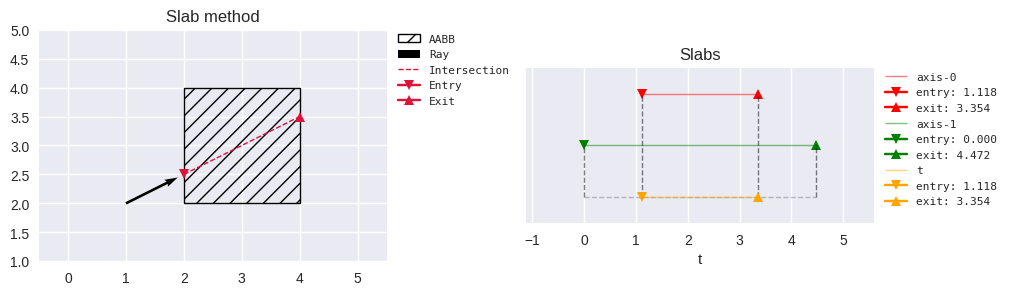

In [5]:
def plot_scene(ro, rd, b_min, b_max, is_hit, t_min, t_max, ax):
    extent = b_max - b_min
    # AABB
    rect = plt.Rectangle(b_min, extent[0], extent[1], edgecolor="black", facecolor="none", linewidth=1, hatch="//", label="AABB")
    ax.add_patch(rect)
    # Ray
    ax.quiver(*ro, *rd, angles="xy", scale_units="xy", scale=1, color="black", label="Ray")
    # Hit
    if is_hit:
        entry_pos = ro + t_min * rd
        exit_pos = ro + t_max * rd
        ax.plot(*np.vstack([entry_pos, exit_pos]).T, color="crimson", linestyle="--", linewidth=1, label="Intersection")
        ax.plot(*entry_pos, color="crimson", marker="v", label="Entry")
        ax.plot(*exit_pos, color="crimson", marker="^", label="Exit")


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), constrained_layout=True)

plot_scene(ro, rd, b_min, b_max, is_hit, t_min, t_max, axes[0])
plot_slabs(t0, t1, axes[1])

# Styling and layout
ax = axes[0]
ax.set_title("Slab method")
ax.margins(x=0.5, y=0.5)
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.0,
    prop=font_manager.FontProperties(family="monospace", size=8),
)

ax = axes[1]
ax.set_title("Slabs")
ax.set_xlabel("t")
ax.margins(x=0.25, y=0.25)
ax.get_yaxis().set_visible(False)
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.0,
    prop=font_manager.FontProperties(family="monospace", size=8),
)

plt.show()

## Appendix: 3次元での可視化

In [6]:
ro, rd = np.array([2, 1, 2]), np.array([4, 4, 2])
rd = rd / np.linalg.norm(rd)

b_min = np.array([2.0, 2.0, 2.0])
b_max = np.array([4.0, 4.0, 4.0])

t0 = (b_min - ro) / rd
t1 = (b_max - ro) / rd

is_hit, t_min, t_max = intersect(ro, rd, b_min, b_max)
print(f"{is_hit=}, {t_min=}, {t_max=}")

is_hit=np.True_, t_min=np.float64(1.5), t_max=np.float64(3.0)


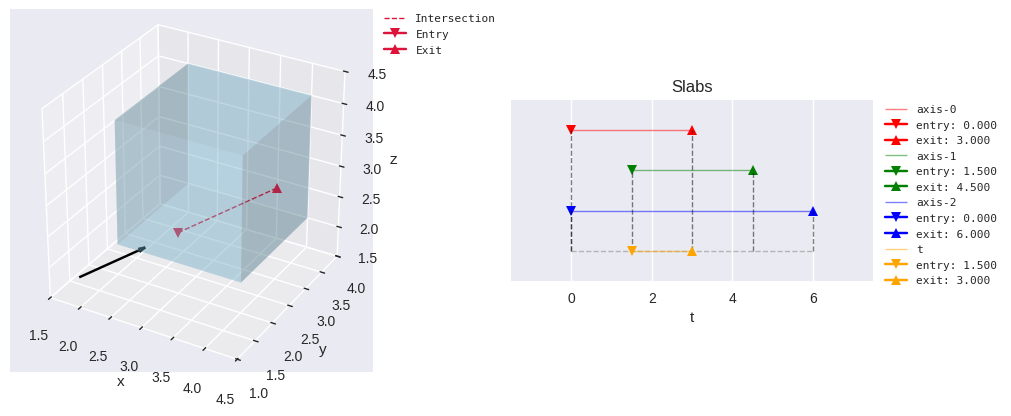

In [7]:
from mpl_toolkits.mplot3d import Axes3D


def plot_aabb(b_min, b_max, ax, **kwargs):
    x, y, z = b_min[0], b_min[1], b_min[2]
    X, Y, Z = b_max[0], b_max[1], b_max[2]

    faces = [
        ("z", x, X, y, Y, z),  # bottom
        ("z", x, X, y, Y, Z),  # top
        ("y", x, X, z, Z, y),  # front
        ("y", x, X, z, Z, Y),  # back
        ("x", y, Y, z, Z, x),  # left
        ("x", y, Y, z, Z, X),  # right
    ]

    for axis, a0, a1, b0, b1, fixed in faces:
        aa, bb = np.meshgrid([a0, a1], [b0, b1])
        surf = {"x": (np.full_like(aa, fixed), aa, bb), "y": (aa, np.full_like(aa, fixed), bb), "z": (aa, bb, np.full_like(aa, fixed))}[axis]
        ax.plot_surface(*surf, **kwargs)


def plot_scene_3d(ro, rd, b_min, b_max, is_hit, t_min, t_max, ax):
    extent = b_max - b_min
    # AABB
    plot_aabb(b_min, b_max, ax, color="skyblue", alpha=0.25)
    # Ray
    ax.quiver(*ro, *rd, length=1.0, normalize=True, color="black", arrow_length_ratio=0.1)
    #
    if is_hit:
        entry_pos = ro + t_min * rd
        exit_pos = ro + t_max * rd
        ax.plot(*np.vstack([entry_pos, exit_pos]).T, color="crimson", linestyle="--", linewidth=1, label="Intersection")
        ax.plot(*entry_pos, color="crimson", marker="v", label="Entry")
        ax.plot(*exit_pos, color="crimson", marker="^", label="Exit")

    pts = [b_min, b_max, ro, ro + rd]
    lower, upper = np.min(pts, axis=0), np.max(pts, axis=0)
    center = 0.5 * (lower + upper)
    extent = upper - lower
    half_max_extent = 0.5 * np.max(extent)

    ax.set_xlim(center[0] - half_max_extent, center[0] + half_max_extent)
    ax.set_ylim(center[1] - half_max_extent, center[1] + half_max_extent)
    ax.set_zlim(center[2] - half_max_extent, center[2] + half_max_extent)
    ax.set_box_aspect([1, 1, 1])


fig = plt.figure(figsize=(10, 5), constrained_layout=True)
ax0 = fig.add_subplot(121, projection="3d")
ax1 = fig.add_subplot(122)

plot_scene_3d(ro, rd, b_min, b_max, is_hit, t_min, t_max, ax0)
plot_slabs(t0, t1, ax1)

# Styling and layout
ax = ax0
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.0,
    prop=font_manager.FontProperties(family="monospace", size=8),
)

ax = ax1
ax.set_title("Slabs")
ax.set_xlabel("t")
ax.margins(x=0.25, y=0.25)
ax.get_yaxis().set_visible(False)
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.0,
    prop=font_manager.FontProperties(family="monospace", size=8),
)

plt.show()

## References
- Wikipedia contributors. (2025, April 23). Slab method. Wikipedia. https://en.wikipedia.org/w/index.php?title=Slab_method&oldid=1287019363
- Tavianator. (2022). Fast, Branchless Ray/Bounding Box Intersections, Part 3: Boundaries. Tavianator.com. https://tavianator.com/2022/ray_box_boundary.html